Logistic Regression – Airline Customer Satisfaction Prediction

Generating synthetic survey data for Airline Customer Satisfaction Prediction.

In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(100)

# Number of rows
n = 1000

# Generate synthetic survey data
data = {
    "Gender": np.random.choice(["Male", "Female"], n),
    "Customer_Type": np.random.choice(["Loyal Customer", "Disloyal Customer"], n),
    "Age": np.random.randint(18, 70, n),
    "Type_of_Travel": np.random.choice(["Business", "Personal"], n),
    "Class": np.random.choice(["Economy", "Economy Plus", "Business"], n),
    "Flight_Distance": np.random.randint(100, 5000, n),
    "Inflight_wifi_service": np.random.randint(0, 6, n),  # 0–5 rating
    "Departure_Arrival_time_convenient": np.random.randint(0, 6, n),
    "Ease_of_Online_booking": np.random.randint(0, 6, n),
    "Food_and_drink": np.random.randint(0, 6, n),
    "Seat_comfort": np.random.randint(0, 6, n),
    "Inflight_entertainment": np.random.randint(0, 6, n),
    "Onboard_service": np.random.randint(0, 6, n),
    "Leg_room_service": np.random.randint(0, 6, n),
    "Baggage_handling": np.random.randint(0, 6, n),
    "Checkin_service": np.random.randint(0, 6, n),
    "Cleanliness": np.random.randint(0, 6, n),
    "Online_boarding": np.random.randint(0, 6, n),
    "Satisfaction": np.random.choice(["Satisfied", "Neutral or Dissatisfied"], n)
}

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
df.to_csv("airline_passenger_survey.csv", index=False)

print("Synthetic dataset generated and saved as airline_passenger_survey.csv")
print(df.head())

Synthetic dataset generated and saved as airline_passenger_survey.csv
   Gender      Customer_Type  Age Type_of_Travel         Class  \
0    Male     Loyal Customer   51       Personal       Economy   
1    Male  Disloyal Customer   44       Personal  Economy Plus   
2  Female  Disloyal Customer   50       Personal  Economy Plus   
3  Female     Loyal Customer   38       Business       Economy   
4  Female     Loyal Customer   66       Business  Economy Plus   

   Flight_Distance  Inflight_wifi_service  Departure_Arrival_time_convenient  \
0             3271                      2                                  2   
1             1964                      3                                  2   
2              295                      1                                  0   
3             1817                      2                                  3   
4             4671                      5                                  0   

   Ease_of_Online_booking  Food_and_drink  Seat_comf

# Step 1: Load and Inspect Dataset

In this step, we load the airline passenger survey dataset and explore its structure.  
We want to:
- Confirm the dataset loads correctly.
- Inspect the target variable (`Satisfaction`) to see how balanced the classes are.
- Get a quick overview of the features and data types.


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("airline_passenger_survey.csv")

# Preview first 5 rows
print("Dataset Preview:")
display(df.head())

Dataset Preview:


,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure_Arrival_time_convenient,Ease_of_Online_booking,Food_and_drink,Seat_comfort,Inflight_entertainment,Onboard_service,Leg_room_service,Baggage_handling,Checkin_service,Cleanliness,Online_boarding,Satisfaction
0,Male,Loyal Customer,51,Personal,Economy,3271,2,2,1,1,2,3,2,2,4,1,0,0,Satisfied
1,Male,Disloyal Customer,44,Personal,Economy Plus,1964,3,2,3,5,3,5,3,0,4,1,3,0,Satisfied
2,Female,Disloyal Customer,50,Personal,Economy Plus,295,1,0,2,0,3,5,5,4,2,4,1,4,Neutral or Dissatisfied
3,Female,Loyal Customer,38,Business,Economy,1817,2,3,1,0,2,2,5,3,0,4,4,4,Satisfied
4,Female,Loyal Customer,66,Business,Economy Plus,4671,5,0,1,2,4,0,3,0,3,1,0,5,Satisfied


In [5]:
# Dataset info (columns, types, missing values)
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Gender                             1000 non-null   str  
 1   Customer_Type                      1000 non-null   str  
 2   Age                                1000 non-null   int64
 3   Type_of_Travel                     1000 non-null   str  
 4   Class                              1000 non-null   str  
 5   Flight_Distance                    1000 non-null   int64
 6   Inflight_wifi_service              1000 non-null   int64
 7   Departure_Arrival_time_convenient  1000 non-null   int64
 8   Ease_of_Online_booking             1000 non-null   int64
 9   Food_and_drink                     1000 non-null   int64
 10  Seat_comfort                       1000 non-null   int64
 11  Inflight_entertainment             1000 non-null   int64
 12  Onboard_service  

In [6]:
# Check target variable distribution
print("\nTarget Variable Distribution:")
print(df['Satisfaction'].value_counts())


Target Variable Distribution:
Satisfaction
Satisfied                  504
Neutral or Dissatisfied    496
Name: count, dtype: int64


A preview of the first 5 rows.

Information about column names, data types, and non-null counts.

Distribution of the target variable (Satisfied vs Neutral or Dissatisfied).

This helps you understand whether the dataset is balanced or skewed, which is important for model evaluation later.

# Step 2: Encode Categorical Predictors

Logistic Regression in Scikit-learn requires numeric inputs.  
In this step, we will:
- Encode the target variable (`Satisfaction`) into binary values (0 = Neutral/Dissatisfied, 1 = Satisfied).
- Convert categorical features (e.g., Gender, Customer_Type, Travel Class, Type_of_Travel) into numeric format using One-Hot Encoding.
- Keep numerical features (like Age, Flight_Distance, service ratings) as they are.


In [7]:
from sklearn.preprocessing import LabelEncoder

# Encode target variable
label_encoder = LabelEncoder()
df['Satisfaction'] = label_encoder.fit_transform(df['Satisfaction'])

# One-hot encode categorical predictors
df_encoded = pd.get_dummies(df, drop_first=True)

print("Encoded dataset preview:")
display(df_encoded.head())

print("\nShape of dataset after encoding:", df_encoded.shape)
from sklearn.model_selection import train_test_split

Encoded dataset preview:


,Age,Flight_Distance,Inflight_wifi_service,Departure_Arrival_time_convenient,Ease_of_Online_booking,Food_and_drink,Seat_comfort,Inflight_entertainment,Onboard_service,Leg_room_service,Baggage_handling,Checkin_service,Cleanliness,Online_boarding,Satisfaction,Gender_Male,Customer_Type_Loyal Customer,Type_of_Travel_Personal,Class_Economy,Class_Economy Plus
0,51,3271,2,2,1,1,2,3,2,2,4,1,0,0,1,True,True,True,True,False
1,44,1964,3,2,3,5,3,5,3,0,4,1,3,0,1,True,False,True,False,True
2,50,295,1,0,2,0,3,5,5,4,2,4,1,4,0,False,False,True,False,True
3,38,1817,2,3,1,0,2,2,5,3,0,4,4,4,1,False,True,False,True,False
4,66,4671,5,0,1,2,4,0,3,0,3,1,0,5,1,False,True,False,False,True



Shape of dataset after encoding: (1000, 20)


The target variable Satisfaction will be encoded as 0 or 1.

Categorical predictors (like Gender, Customer_Type, Class, Type_of_Travel) will be expanded into multiple binary columns.

The dataset will now be fully numeric and ready for model training.

# Step 3: Split Data into Training and Testing Sets

To evaluate our model fairly, we split the dataset into:
- **Training set**: used to fit the Logistic Regression model.
- **Testing set**: used to evaluate model performance on unseen data.

We’ll use an 80/20 split and apply **stratification** to preserve the balance of the target variable (`Satisfaction`).


In [8]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_encoded.drop('Satisfaction', axis=1)
y = df_encoded['Satisfaction']

# Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nTarget distribution in testing set:")
print(y_test.value_counts(normalize=True))

Training set shape: (800, 19)
Testing set shape: (200, 19)

Target distribution in training set:
Satisfaction
1    0.50375
0    0.49625
Name: proportion, dtype: float64

Target distribution in testing set:
Satisfaction
1    0.505
0    0.495
Name: proportion, dtype: float64


Shapes of training and testing sets.

Distribution of the target variable in both sets (to confirm stratification worked).

Now you have clean splits ready for model training.

# Step 4: Build Logistic Regression Model

Now that we have preprocessed the data and split it into training and testing sets,  
we can build a **Logistic Regression model** using Scikit-learn.

Steps:
- Initialize the Logistic Regression model.
- Fit the model on the training set.
- Generate predictions on the test set.


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv("airline_passenger_survey.csv")

# Encode target column
le = LabelEncoder()
y = le.fit_transform(data['Satisfaction'])

# Prepare features (convert categorical to numeric)
X = pd.get_dummies(data.drop('Satisfaction', axis=1), drop_first=True)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# Train Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=100)
log_reg.fit(X_train, y_train)

# Predict and show results
y_pred = log_reg.predict(X_test)
print("Model training complete.")
print("First 10 predictions:", y_pred[:10])


Model training complete.
First 10 predictions: [0 0 0 1 1 1 0 0 1 0]


Confirmation that the model has been trained.

A preview of the first 10 predictions (0 = Neutral/Dissatisfied, 1 = Satisfied).

At this stage, the model is ready for evaluation.

# Step 5: Model Evaluation

Accuracy alone can be misleading, especially if the dataset is imbalanced.  
To properly evaluate our Logistic Regression model, we will:
- Generate a **Confusion Matrix** to visualize true positives, false positives, true negatives, and false negatives.
- Calculate **Precision** (how many predicted positives are correct).
- Calculate **Recall** (how many actual positives were correctly identified).
- Compare with **Accuracy** to understand trade-offs.


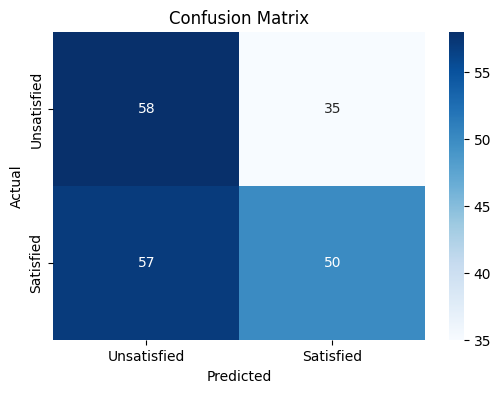

Model Performance Metrics:
Accuracy : 0.54
Precision: 0.588
Recall   : 0.467


In [10]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Unsatisfied','Satisfied'], yticklabels=['Unsatisfied','Satisfied'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Precision, Recall, Accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Model Performance Metrics:")
print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))

A heatmap confusion matrix showing prediction outcomes.

Performance metrics: Accuracy, Precision, Recall.

This helps to understand whether the model is better at avoiding false positives or false negatives, which is crucial for business decisions.

# Step 6: Interpret Model Coefficients (Feature Importance)

Logistic Regression provides coefficients for each feature.  
These coefficients indicate how strongly each predictor influences the probability of passenger satisfaction:

- **Positive coefficients** → increase likelihood of satisfaction.  
- **Negative coefficients** → decrease likelihood of satisfaction.  

We’ll sort and display the coefficients to identify the most important drivers of satisfaction.

In [13]:
import pandas as pd

# Extract coefficients
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# Top positive drivers
print("Top Positive Drivers of Satisfaction:")
display(coefficients.head(10))

Top Positive Drivers of Satisfaction:


,Feature,Coefficient
17,Class_Economy,0.484297
14,Gender_Male,0.149899
16,Type_of_Travel_Personal,0.110941
8,Onboard_service,0.077019
15,Customer_Type_Loyal Customer,0.060817
6,Seat_comfort,0.048592
9,Leg_room_service,0.040120
11,Checkin_service,0.014658
3,Departure_Arrival_time_convenient,0.012373
1,Flight_Distance,-0.000042


In [14]:
# Top negative drivers
print("Top Negative Drivers of Satisfaction:")
display(coefficients.tail(10))

Top Negative Drivers of Satisfaction:


,Feature,Coefficient
1,Flight_Distance,-0.000042
0,Age,-0.003219
10,Baggage_handling,-0.003535
13,Online_boarding,-0.009037
5,Food_and_drink,-0.009636
12,Cleanliness,-0.027825
7,Inflight_entertainment,-0.033185
4,Ease_of_Online_booking,-0.053248
2,Inflight_wifi_service,-0.057156
18,Class_Economy Plus,-0.058777


A sorted list of features with their coefficients.

The top positive drivers (e.g., good Wi-Fi, seat comfort, cleanliness) that increase satisfaction.

The top negative drivers (e.g., poor check-in service, inconvenient departure times) that reduce satisfaction.

This step connects the model back to business insights — showing the airline which areas to prioritize for improving customer satisfaction.

# Step 7: Business Recommendations

Based on the model coefficients and evaluation metrics, we can translate insights into actionable strategies.  
The goal is to help the airline improve customer satisfaction and retention.

Examples of recommendations:
- If **Inflight Wi-Fi** has a strong negative coefficient, prioritize upgrading connectivity.
- If **Seat Comfort** is a strong positive driver, invest in better seating arrangements.
- If **Check-in Service** shows a negative impact, streamline check-in processes.
- If **Cleanliness** is highly positive, maintain and enhance cleaning protocols.

We will extract the most influential features and provide business-oriented suggestions.

In [15]:
# Identify top drivers (positive and negative)
top_positive = coefficients.head(5)
top_negative = coefficients.tail(5)

print("Top Positive Drivers (increase satisfaction):")
display(top_positive)

print("Top Negative Drivers (decrease satisfaction):")
display(top_negative)

# Example recommendations (manual interpretation based on coefficients)
recommendations = [
    "Improve inflight Wi-Fi quality to boost satisfaction among business travelers.",
    "Enhance seat comfort to increase satisfaction probability for long-haul flights.",
    "Streamline check-in service to reduce dissatisfaction at the start of the journey.",
    "Maintain high cleanliness standards as it strongly correlates with satisfaction.",
    "Optimize departure/arrival time convenience to reduce dissatisfaction."
]

print("\nBusiness Recommendations:")
for rec in recommendations:
    print("-", rec)

Top Positive Drivers (increase satisfaction):


,Feature,Coefficient
17,Class_Economy,0.484297
14,Gender_Male,0.149899
16,Type_of_Travel_Personal,0.110941
8,Onboard_service,0.077019
15,Customer_Type_Loyal Customer,0.060817


Top Negative Drivers (decrease satisfaction):


,Feature,Coefficient
12,Cleanliness,-0.027825
7,Inflight_entertainment,-0.033185
4,Ease_of_Online_booking,-0.053248
2,Inflight_wifi_service,-0.057156
18,Class_Economy Plus,-0.058777



Business Recommendations:
- Improve inflight Wi-Fi quality to boost satisfaction among business travelers.
- Enhance seat comfort to increase satisfaction probability for long-haul flights.
- Streamline check-in service to reduce dissatisfaction at the start of the journey.
- Maintain high cleanliness standards as it strongly correlates with satisfaction.
- Optimize departure/arrival time convenience to reduce dissatisfaction.


# Bonus: Visualize Feature Importance

Numbers alone can be hard to interpret.  
To make the model insights clearer, we’ll plot a bar chart of the logistic regression coefficients:

- Features with **positive coefficients** increase satisfaction probability.
- Features with **negative coefficients** decrease satisfaction probability.
- The magnitude of the coefficient shows the strength of influence.


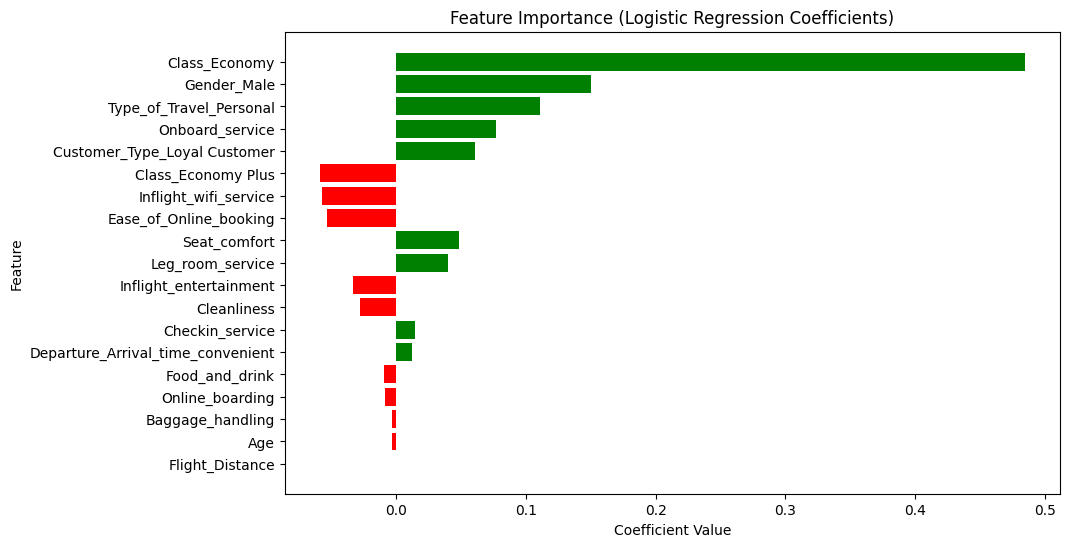

In [16]:
import matplotlib.pyplot as plt

# Sort coefficients by absolute value (importance)
coeff_sorted = coefficients.reindex(coefficients.Coefficient.abs().sort_values(ascending=False).index)

# Plot bar chart
plt.figure(figsize=(10,6))
plt.barh(coeff_sorted['Feature'], coeff_sorted['Coefficient'], color=['green' if c > 0 else 'red' for c in coeff_sorted['Coefficient']])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.gca().invert_yaxis()  # Highest importance at top
plt.show()

A horizontal bar chart with features sorted by importance.

Green bars = positive drivers of satisfaction.

Red bars = negative drivers of satisfaction.

This makes it visually clear which factors matter most.

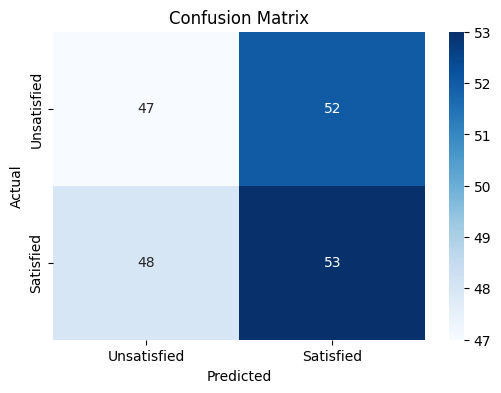

In [17]:
# Save confusion matrix plot as PNG
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Unsatisfied','Satisfied'], 
            yticklabels=['Unsatisfied','Satisfied'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

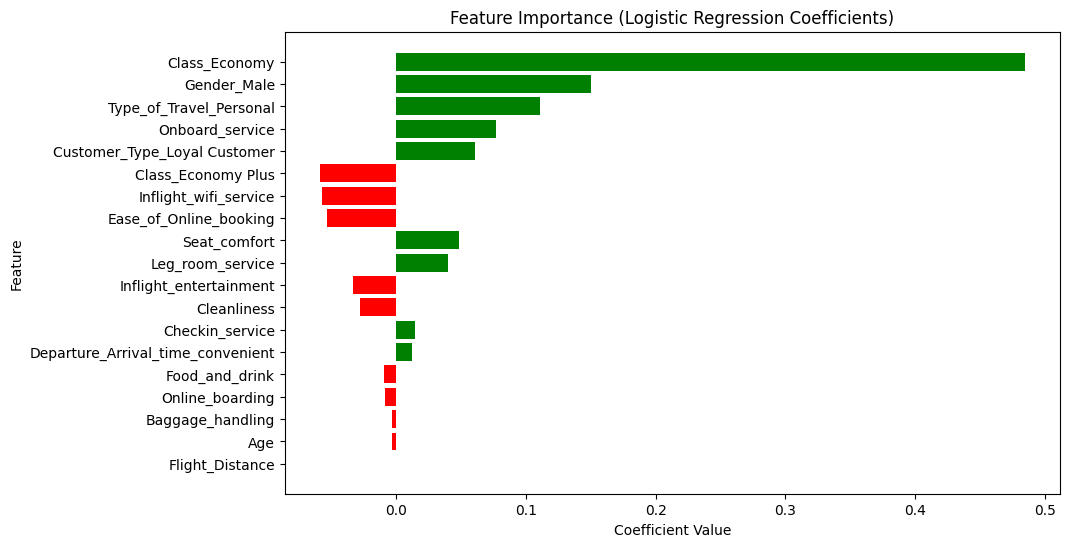

In [18]:
# Save feature importance plot as PNG
plt.figure(figsize=(10,6))
plt.barh(coeff_sorted['Feature'], coeff_sorted['Coefficient'], 
         color=['green' if c > 0 else 'red' for c in coeff_sorted['Coefficient']])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.gca().invert_yaxis()  # Highest importance at top
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()